In [26]:
import pandas as pd
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

# 1. Simpan DataFrame ke Excel
excel_file = "lbo_screened_results.xlsx"
df_screener.to_excel(excel_file, index=False)

# 2. Buka Workbook untuk Memberi Styling Profesional
wb = openpyxl.load_workbook(excel_file)
ws = wb.active
ws.title = "LBO Screening"
ws.views.sheetView[0].showGridLines = True  # Tampilkan garis sel

# Warna Header (Dark Blue)
header_fill = PatternFill(start_color="1F4E78", end_color="1F4E78", fill_type="solid")
header_font = Font(name="Calibri", size=11, bold=True, color="FFFFFF")

# Warna Status Highlight
fill_green = PatternFill(start_color="E2EFDA", end_color="E2EFDA", fill_type="solid")
font_green = Font(name="Calibri", size=10, bold=True, color="276A3C")

fill_yellow = PatternFill(start_color="FFF2CC", end_color="FFF2CC", fill_type="solid")
font_yellow = Font(name="Calibri", size=10, color="7F6000")

fill_red = PatternFill(start_color="FCE4D6", end_color="FCE4D6", fill_type="solid")
font_red = Font(name="Calibri", size=10, color="C65911")

# Style Header Row
for col_num in range(1, len(df_screener.columns) + 1):
    cell = ws.cell(row=1, column=col_num)
    cell.fill = header_fill
    cell.font = header_font
    cell.alignment = Alignment(horizontal="center", vertical="center")

# Highlight Kolom Status & Atur Alignment Data
status_col_idx = df_screener.columns.get_loc("Status LBO") + 1

for row_num in range(2, len(df_screener) + 2):
    cell_status = ws.cell(row=row_num, column=status_col_idx)
    val = str(cell_status.value or "")
    if "POTENSIAL" in val:
        cell_status.fill = fill_green
        cell_status.font = font_green
    elif "MAHAL" in val:
        cell_status.fill = fill_yellow
        cell_status.font = font_yellow
    elif "RISKY" in val:
        cell_status.fill = fill_red
        cell_status.font = font_red

# Auto-Fit Lebar Kolom
for col in ws.columns:
    max_len = max(len(str(cell.value or '')) for cell in col)
    col_letter = get_column_letter(col[0].column)
    ws.column_dimensions[col_letter].width = max(max_len + 4, 12)

wb.save(excel_file)
print(f"✅ File Excel rapi berhasil disimpan sebagai: {excel_file}")

✅ File Excel rapi berhasil disimpan sebagai: lbo_screened_results.xlsx


In [27]:
import yfinance as yf
import pandas as pd
import numpy as np

def analyze_swing_big_trade(ticker_symbol):
    try:
        # Tarik data historis harian 6 bulan terakhir
        stock = yf.Ticker(ticker_symbol)
        hist = stock.history(period="6m")
        
        if len(hist) < 50:
            return None
        
        # 1. Hitung Moving Averages
        hist['SMA_20'] = hist['Close'].rolling(window=20).mean()
        hist['SMA_50'] = hist['Close'].rolling(window=50).mean()
        
        latest = hist.iloc[-1]
        prev_20 = hist.iloc[-20] # Harga 1 bulan lalu (~20 hari bursa)
        
        # 2. Hitung Return 1-Bulan (%)
        one_month_return = ((latest['Close'] - prev_20['Close']) / prev_20['Close']) * 100
        
        # 3. Hitung Volume Surge (Volume hari ini dibanding Rata-rata 20 Hari)
        avg_vol_20 = hist['Volume'].tail(20).mean()
        vol_surge = latest['Volume'] / avg_vol_20 if avg_vol_20 > 0 else 1.0
        
        # 4. Hitung Jarak ke 52-Week High
        high_52w = hist['High'].max()
        dist_to_high = ((latest['Close'] - high_52w) / high_52w) * 100
        
        # 5. Hitung RSI (Relative Strength Index) 14 Hari
        delta = hist['Close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
        rs = gain / loss
        rsi = 100 - (100 / (1 + rs.iloc[-1]))
        
        # Kriteria "Big Trade Setup" (1-2 Bulan)
        is_uptrend = (latest['Close'] > latest['SMA_20']) and (latest['SMA_20'] > latest['SMA_50'])
        is_accumulating = vol_surge >= 1.2  # Volume 20% di atas rata-rata
        near_breakout = dist_to_high >= -10.0 # Jarak ke ATH/52W High kurang dari 10%
        healthy_rsi = 50 <= rsi <= 70 # Momentum kuat tapi belum overbought parah
        
        if is_uptrend and near_breakout and healthy_rsi:
            status = "BIG TRADE READY 🚀"
        elif is_uptrend:
            status = "UPTREND (Wait Setup) 📈"
        else:
            status = "NO MOMENTUM 💤"
            
        return {
            "Ticker": ticker_symbol,
            "Price ($)": round(latest['Close'], 2),
            "1M Return (%)": round(one_month_return, 1),
            "Vol Surge": f"{round(vol_surge, 1)}x",
            "RSI (14)": round(rsi, 1),
            "Dist to 52W High": f"{round(dist_to_high, 1)}%",
            "Signal 1-2M": status
        }
    except Exception as e:
        return None

# Pindai 50 saham sampel dari list us_tickers kamu
target_swing_list = us_tickers[:50] 

print("⚡ Memulai Screening Swing / Big Trade (Horizon 1-2 Bulan)...")
swing_results = []

for ticker in target_swing_list:
    res = analyze_swing_big_trade(ticker)
    if res:
        swing_results.append(res)

df_swing = pd.DataFrame(swing_results)

# Filter hanya yang berstatus BIG TRADE READY atau UPTREND
df_big_trade = df_swing[df_swing['Signal 1-2M'] == "BIG TRADE READY 🚀"].sort_values(
    by="1M Return (%)", ascending=False
)

df_big_trade.to_excel("swing_big_trade_candidates.xlsx", index=False)
print(f"\n✅ Selesai! Ditemukan {len(df_big_trade)} saham berpotensi Big Trade dalam 1-2 bulan.\n")
df_big_trade

⚡ Memulai Screening Swing / Big Trade (Horizon 1-2 Bulan)...


MMM: Period '6m' is invalid, must be one of: 1d, 5d, 1mo, 3mo, 6mo, 1y, 2y, 5y, 10y, ytd, max
AOS: Period '6m' is invalid, must be one of: 1d, 5d, 1mo, 3mo, 6mo, 1y, 2y, 5y, 10y, ytd, max
ABT: Period '6m' is invalid, must be one of: 1d, 5d, 1mo, 3mo, 6mo, 1y, 2y, 5y, 10y, ytd, max
ABBV: Period '6m' is invalid, must be one of: 1d, 5d, 1mo, 3mo, 6mo, 1y, 2y, 5y, 10y, ytd, max
ACN: Period '6m' is invalid, must be one of: 1d, 5d, 1mo, 3mo, 6mo, 1y, 2y, 5y, 10y, ytd, max
ADBE: Period '6m' is invalid, must be one of: 1d, 5d, 1mo, 3mo, 6mo, 1y, 2y, 5y, 10y, ytd, max
AMD: Period '6m' is invalid, must be one of: 1d, 5d, 1mo, 3mo, 6mo, 1y, 2y, 5y, 10y, ytd, max
AES: Period '6m' is invalid, must be one of: 1d, 5d, 1mo, 3mo, 6mo, 1y, 2y, 5y, 10y, ytd, max
AFL: Period '6m' is invalid, must be one of: 1d, 5d, 1mo, 3mo, 6mo, 1y, 2y, 5y, 10y, ytd, max
A: Period '6m' is invalid, must be one of: 1d, 5d, 1mo, 3mo, 6mo, 1y, 2y, 5y, 10y, ytd, max
APD: Period '6m' is invalid, must be one of: 1d, 5d, 1mo, 3m

KeyError: 'Signal 1-2M'

In [12]:
!pip install tqdm


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [13]:
from tqdm import tqdm
import time

print(" Memulai Full Screening 500 Saham S&P 500...")
results = []

# Pakai tqdm untuk melihat progress bar & sisa waktu
for ticker in tqdm(us_tickers):
    res = analyze_lbo_candidate(ticker)
    if res:
        results.append(res)
    time.sleep(0.2) # Jeda kecil agar tidak kena rate limit

df_full = pd.DataFrame(results)

# Filter hanya kandidat yang POTENSIAL LBO
df_potensial = df_full[df_full['Status LBO'] == "POTENSIAL LBO 🎯"]
print(f"\nDitemukan {len(df_potensial)} perusahaan potensial target LBO!")
df_potensial.head()

 Memulai Full Screening 500 Saham S&P 500...


100%|██████████| 503/503 [03:03<00:00,  2.74it/s]


Ditemukan 139 perusahaan potensial target LBO!


,Ticker,Nama Perusahaan,Mkt Cap ($B),EV ($B),EV/EBITDA,Net Debt ($B),FCF ($B),Profit Margin,Status LBO
1,AOS,A.O. Smith Corporation,7.95,8.47,10.8,0.50,0.48,13.1%,POTENSIAL LBO 🎯
4,ACN,Accenture plc,106.22,107.60,8.31,-1.78,12.09,10.7%,POTENSIAL LBO 🎯
5,ADBE,Adobe Inc.,91.61,92.79,9.36,1.14,9.35,28.0%,POTENSIAL LBO 🎯
8,AFL,AFLAC Incorporated,57.26,64.25,10.59,7.24,5.15,26.9%,POTENSIAL LBO 🎯
13,ALB,Albemarle Corporation,12.76,15.81,10.66,0.37,1.33,3.8%,POTENSIAL LBO 🎯


In [14]:
import numpy as np

def calculate_lbo_returns(ticker_symbol, holding_years=5, debt_ratio=0.60, interest_rate=0.07):
    """
    Simulasi LBO 5-Tahun untuk Menghitung Sponsor IRR % dan MoIC (Multiple on Invested Capital)
    """
    stock = yf.Ticker(ticker_symbol)
    info = stock.info
    
    # Data Finansial
    ev = (info.get('enterpriseValue') or 0) / 1e9
    ebitda = (info.get('ebitda') or 0) / 1e9
    fcf = (info.get('freeCashflow') or 0) / 1e9
    rev_growth = info.get('revenueGrowth') or 0.03 # Default 3% jika None
    
    if ev == 0 or ebitda == 0 or fcf <= 0:
        return "Data tidak lengkap atau FCF negatif"
    
    entry_multiple = ev / ebitda
    
    # 1. Struktur Transaksi Awal (T0)
    debt_entry = ev * debt_ratio          # 60% Utang
    equity_entry = ev * (1 - debt_ratio)   # 40% Modal Sendiri (PE Sponsor Equity)
    
    # 2. Proyeksi 5 Tahun (Paydown Utang via Free Cash Flow)
    current_fcf = fcf
    current_ebitda = ebitda
    total_fcf_generated = 0
    
    for year in range(1, holding_years + 1):
        # Asumsi pertumbuhan EBITDA & FCF sejalan dengan pertumbuhan revenue
        current_ebitda *= (1 + rev_growth)
        current_fcf *= (1 + rev_growth)
        
        # Bayar bunga utang dulu, sisanya untuk melunasi pokok utang
        interest_expense = debt_entry * interest_rate
        fcf_after_interest = max(0, current_fcf - interest_expense)
        
        # Pelunasan utang
        debt_entry = max(0, debt_entry - fcf_after_interest)
    
    # 3. Asumsi Exit di Tahun ke-5 (Exit pada Multiple EV/EBITDA yang sama)
    exit_ev = current_ebitda * entry_multiple
    exit_equity = exit_ev - debt_entry # Sisa nilai ekuitas setelah pelunasan utang
    
    # 4. Hitung Metrik Imbal Hasil PE (MoIC & IRR)
    moic = exit_equity / equity_entry
    irr = (moic ** (1 / holding_years)) - 1
    
    return {
        "Ticker": ticker_symbol,
        "Entry EV ($B)": round(ev, 2),
        "Entry Equity ($B)": round(equity_entry, 2),
        "Exit EV ($B)": round(exit_ev, 2),
        "Exit Equity ($B)": round(exit_equity, 2),
        "5-Yr MoIC": f"{round(moic, 2)}x",
        "5-Yr IRR": f"{round(irr * 100, 2)}%",
        "LBO Viable (>20% IRR)": "YES 🚀" if irr >= 0.20 else "NO ⚠️"
    }

# Tes simulasi LBO 5-Tahun pada salah satu hasil screening kamu (misal: BBY / Best Buy)
calculate_lbo_returns("BBY")

{'Ticker': 'BBY',
 'Entry EV ($B)': 20.71,
 'Entry Equity ($B)': 8.29,
 'Exit EV ($B)': 24.72,
 'Exit Equity ($B)': 16.23,
 '5-Yr MoIC': '1.96x',
 '5-Yr IRR': '14.4%',
 'LBO Viable (>20% IRR)': 'NO ⚠️'}

In [15]:
# Sesuaikan nama dataframe hasil screening kamu di sini
potensial_df = df_full[df_full['Status LBO'] == "POTENSIAL LBO 🎯"].copy()


In [18]:
# 1. Filter hanya saham yang lolos kriteria awal LBO
potensial_df = df_full[df_full['Status LBO'] == "POTENSIAL LBO 🎯"].copy()

print(f"Memproses kalkulasi LBO Return untuk {len(potensial_df)} kandidat potensial...\n")

lbo_evaluations = []
for ticker in potensial_df['Ticker']:
    res = calculate_lbo_returns(ticker)
    if isinstance(res, dict): # Jika hasil kalkulasi sukses
        lbo_evaluations.append(res)

# 2. Buat DataFrame dan bersihkan kolom IRR untuk sorting
df_lbo_ranked = pd.DataFrame(lbo_evaluations)

# Convert string IRR (misal '25.4%') ke angka float untuk pengurutan
df_lbo_ranked['IRR_Num'] = df_lbo_ranked['5-Yr IRR'].str.rstrip('%').astype(float)

# Sort dari IRR tertinggi ke terendah
df_lbo_ranked = df_lbo_ranked.sort_values(by='IRR_Num', ascending=False).drop(columns=['IRR_Num'])

# Simpan ke Excel khusus Top LBO Target
df_lbo_ranked.to_excel("top_lbo_targets_ranked.xlsx", index=False)

print("🏆 TOP 5 KANDIDAT TARGET LBO DENGAN IRR TERTIAN:")
df_lbo_ranked.head(5)

Memproses kalkulasi LBO Return untuk 139 kandidat potensial...

🏆 TOP 5 KANDIDAT TARGET LBO DENGAN IRR TERTIAN:


,Ticker,Entry EV ($B),Entry Equity ($B),Exit EV ($B),Exit Equity ($B),5-Yr MoIC,5-Yr IRR,LBO Viable (>20% IRR)
70,GPN,41.89,16.76,570.72,570.72,34.06x,102.51%,YES 🚀
102,OMC,29.90,11.96,348.23,348.23,29.12x,96.26%,YES 🚀
43,DVN,62.70,25.08,748.38,721.69,28.78x,95.8%,YES 🚀
51,EOG,76.96,30.78,774.74,774.74,25.17x,90.62%,YES 🚀
95,MPC,143.68,57.47,1232.42,1232.42,21.44x,84.61%,YES 🚀


In [30]:
import yfinance as yf
import pandas as pd
import numpy as np
from tqdm import tqdm

# ==========================================
# 1. FETCH & TAG TICKERS DARI S&P 500 & QQQ
# ==========================================
print("🔍 Mengambil & Menggabungkan Ticker dari S&P 500 dan Nasdaq-100...")

try:
    # S&P 500
    sp500_df = pd.read_html("https://en.wikipedia.org/wiki/List_of_S%26P_500_companies")[0]
    sp500_tickers = sp500_df['Symbol'].tolist()
    
    # Nasdaq-100
    qqq_tables = pd.read_html("https://en.wikipedia.org/wiki/Nasdaq-100")
    qqq_df = qqq_tables[4] if len(qqq_tables) > 4 else qqq_tables[3]
    qqq_tickers = qqq_df['Ticker'].tolist()
except Exception as e:
    print(f"Error fetching wikipedia tables: {e}")
    # Fallback list jika koneksi wikipedia bermasalah
    sp500_tickers = ["AAPL", "MSFT", "AMZN", "NVDA", "GOOGL", "MMM", "ADM", "BBY", "WBA", "INTC", "GPN", "JNJ", "PFE"]
    qqq_tickers = ["AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "META", "TSLA", "AVGO", "COST", "PEP", "GILD", "PYPL", "CMCSA"]

# Pembersihan format ticker (Ganti dot dengan hyphen)
sp500_clean = [t.replace('.', '-') for t in sp500_tickers]
qqq_clean = [t.replace('.', '-') for t in qqq_tickers]

# Tagging Asal Indeks
ticker_index_map = {}
for t in sp500_clean:
    ticker_index_map[t] = ["S&P 500"]

for t in qqq_clean:
    if t in ticker_index_map:
        ticker_index_map[t].append("Nasdaq-100")
    else:
        ticker_index_map[t] = ["Nasdaq-100"]

all_unique_tickers = list(ticker_index_map.keys())

print(f"✅ Total Ticker Unik Terkumpul: {len(all_unique_tickers)} Perusahaan")
print(f"   - S&P 500 Only : {sum(1 for v in ticker_index_map.values() if v == ['S&P 500'])}")
print(f"   - Nasdaq-100 Only: {sum(1 for v in ticker_index_map.values() if v == ['Nasdaq-100'])}")
print(f"   - Both Indices  : {sum(1 for v in ticker_index_map.values() if len(v) > 1)}\n")

# ==========================================
# 2. LBO SCREENER & RETURN ENGINE
# ==========================================
def run_lbo_model(ticker_symbol, leverage_ratio=3.5, max_rev_growth=0.05, hold_period=5):
    try:
        stock = yf.Ticker(ticker_symbol)
        info = stock.info
        
        # 1. Fetch Key Metrics
        market_cap = info.get('marketCap', 0)
        total_debt = info.get('totalDebt', 0)
        total_cash = info.get('totalCash', 0)
        ebitda = info.get('ebitda', 0)
        fcf = info.get('freeCashflow', 0)
        sector = info.get('sector', 'Unknown')
        
        if not market_cap or not ebitda or ebitda <= 0 or not fcf or fcf <= 0:
            return None
        
        # Enterprise Value & Initial Leverage
        ev = market_cap + total_debt - total_cash
        entry_ev_ebitda = ev / ebitda
        
        # Saring awal: Hindari EV/EBITDA yang terlalu mahal (> 25x)
        if entry_ev_ebitda > 25:
            return None
            
        # 2. Historical Revenue CAGR & Cap Pertumbuhan
        financials = stock.financials
        if financials is not None and not financials.empty and 'Total Revenue' in financials.index:
            rev_data = financials.loc['Total Revenue'].dropna()
            if len(rev_data) >= 3:
                rev_recent = rev_data.iloc[0]
                rev_old = rev_data.iloc[-1]
                years = len(rev_data) - 1
                cagr = (rev_recent / rev_old) ** (1 / years) - 1 if rev_old > 0 else 0.03
            else:
                cagr = 0.03
        else:
            cagr = 0.03
            
        # Cap Revenue Growth agar realistis (Contoh: Max 5% per tahun)
        proj_rev_growth = min(max(cagr, 0.01), max_rev_growth)
        
        # 3. LBO Structure (Sponsor Equity & Debt)
        spons_debt = min(leverage_ratio * ebitda, ev * 0.7) # Utang maks 70% LTV atau 3.5x EBITDA
        spons_equity = ev - spons_debt
        
        if spons_equity <= 0:
            return None
            
        # 4. 5-Year Projection
        current_ebitda = ebitda
        cumulative_fcf = 0
        
        for _ in range(hold_period):
            current_ebitda *= (1 + proj_rev_growth)
            proj_fcf = fcf * (current_ebitda / ebitda)
            cumulative_fcf += proj_fcf
            
        # Debt Paydown (80% FCF dipakai pelunasan utang)
        debt_paid = cumulative_fcf * 0.8
        remaining_debt = max(0, spons_debt - debt_paid)
        
        # Exit Valuation (Multiple Exit = Entry Multiple)
        exit_ev = current_ebitda * entry_ev_ebitda
        exit_equity = exit_ev - remaining_debt
        
        # Returns Calculation
        moic = exit_equity / spons_equity if spons_equity > 0 else 0
        
        if moic > 0:
            irr = (moic ** (1 / hold_period) - 1) * 100
        else:
            irr = -100.0
            
        # Tag Index Origin
        idx_list = ticker_index_map[ticker_symbol]
        idx_str = "S&P 500 & QQQ" if len(idx_list) > 1 else idx_list[0]
            
        return {
            "Ticker": ticker_symbol,
            "Index": idx_str,
            "Sector": sector,
            "Price ($)": round(info.get('currentPrice', 0), 2),
            "EV ($B)": round(ev / 1e9, 2),
            "EV/EBITDA (x)": round(entry_ev_ebitda, 1),
            "FCF Yield (%)": round((fcf / market_cap) * 100, 1),
            "Proj Rev Growth": f"{round(proj_rev_growth * 100, 1)}%",
            "5Y Debt Paid ($B)": round(debt_paid / 1e9, 2),
            "Exit Equity ($B)": round(exit_equity / 1e9, 2),
            "5Y MoIC (x)": round(moic, 2),
            "5Y Sponsor IRR (%)": round(irr, 1)
        }
    except Exception:
        return None

# ==========================================
# 3. RUNNING SCREENER OVER ALL TICKERS
# ==========================================
lbo_results = []
print("🚀 Memulai Screening LBO 5-Tahun untuk S&P 500 + Nasdaq-100...")

# Pindai seluruh ticker (Gunakan subset [:100] jika mau testing cepat)
for ticker in tqdm(all_unique_tickers):
    res = run_lbo_model(ticker)
    if res:
        lbo_results.append(res)

df_all_lbo = pd.DataFrame(lbo_results)

# Filter Kandidat LBO Terbaik: IRR >= 15% & EV/EBITDA <= 15x
df_top_lbo = df_all_lbo[
    (df_all_lbo['5Y Sponsor IRR (%)'] >= 15.0) & 
    (df_all_lbo['EV/EBITDA (x)'] <= 15.0)
].sort_values(by="5Y Sponsor IRR (%)", ascending=False)

# ==========================================
# 4. EXPORT HASIL KE EXCEL (MULTI-SHEET)
# ==========================================
excel_file = "Multi_Index_5Y_LBO_Project.xlsx"
with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:
    df_top_lbo.to_excel(writer, sheet_name='Top LBO Candidates', index=False)
    df_all_lbo.sort_values(by="5Y Sponsor IRR (%)", ascending=False).to_excel(
        writer, sheet_name='All Screened Companies', index=False
    )

print(f"\n✅ Selesai! {len(df_top_lbo)} perusahaan berhasil lolos kriteria LBO.")
print(f"📁 File Excel tersimpan: '{excel_file}'\n")

# Tampilkan 10 Kandidat LBO Teratas
df_top_lbo.head(10)

🔍 Mengambil & Menggabungkan Ticker dari S&P 500 dan Nasdaq-100...
Error fetching wikipedia tables: HTTP Error 403: Forbidden
✅ Total Ticker Unik Terkumpul: 21 Perusahaan
   - S&P 500 Only : 8
   - Nasdaq-100 Only: 8
   - Both Indices  : 5

🚀 Memulai Screening LBO 5-Tahun untuk S&P 500 + Nasdaq-100...


100%|██████████| 21/21 [00:02<00:00,  7.62it/s]


✅ Selesai! 2 perusahaan berhasil lolos kriteria LBO.
📁 File Excel tersimpan: 'Multi_Index_5Y_LBO_Project.xlsx'



,Ticker,Index,Sector,Price ($),EV ($B),EV/EBITDA (x),FCF Yield (%),Proj Rev Growth,5Y Debt Paid ($B),Exit Equity ($B),5Y MoIC (x),5Y Sponsor IRR (%)
12,PYPL,Nasdaq-100,Financial Services,54.05,49.2,7.6,9.6,5.0%,20.53,60.73,2.28,17.9
13,CMCSA,Nasdaq-100,Communication Services,21.66,159.6,4.7,16.5,1.0%,52.33,108.36,2.26,17.7


In [39]:
import pandas as pd
import openpyxl
from openpyxl.styles import Font, Alignment, PatternFill, Border, Side
from openpyxl.utils import get_column_letter

# 1. Ambil 4 Kandidat Qualified
df_top4 = df_qualified_lbo.head(4).copy()

# ==========================================
# 2. CETAK EXECUTIVE REPORT DI TERMINAL / CONSOLE
# ==========================================
report_text = f"""
================================================================================
                    PRIVATE EQUITY EXECUTIVE LBO REPORT
                   Target Universe: S&P 500 & Nasdaq-100
================================================================================
DATE               : September 2026
TOTAL QUALIFIED    : {len(df_top4)} Companies (Passed All Solvency & Return Gates)
CRITERIA PASSED    : Min DSCR >= 1.25x | Min Int Coverage >= 2.5x | FCF Conv >= 50%
================================================================================

1. EXECUTIVE SUMMARY & INVESTMENT THESIS
--------------------------------------------------------------------------------
Dari seluruh konstituen S&P 500 dan Nasdaq-100, hanya {len(df_top4)} perusahaan yang berhasil
lolos kriteria kelayakan LBO institusional. Seluruh kandidat ini memiliki profil
risiko terukur dengan daya tahan solvabilitas tinggi terhadap fluktuasi suku bunga.

Pilar Utama Value Creation:
• Aggressive Deleveraging: FCF Conversion > 50% memungkinkan pelunasan utang
  hingga Exit Debt/EBITDA < 2.0x di Year 5.
• Rate Shock Buffer: Min DSCR >= 1.25x dan Interest Coverage >= 2.5x menjamin
  keamanan pembayaran bunga utang mengambang.
• Margin of Safety: Hasil imbal hasil (IRR) tetap kompetitif meskipun dikenakan
  penalti Exit Multiple Contraction (-1.0x EBITDA).

2. QUALIFIED TARGETS SUMMARY
--------------------------------------------------------------------------------
"""
print(report_text)
print(df_top4[['Ticker', 'Index', 'Sector', 'EV/EBITDA (x)', 'Min DSCR (x)', '5Y MoIC (x)', '5Y Sponsor IRR (%)']].to_string(index=False))

# ==========================================
# 3. EXPORT KE EXCEL DENGAN STYLING RAPI
# ==========================================
file_name = "Executive_LBO_Report_MultiIndex.xlsx"

with pd.ExcelWriter(file_name, engine='openpyxl') as writer:
    # Write Sheet 2 & 3 first
    df_top4.to_excel(writer, sheet_name='Top 4 Detailed Comparison', index=False)
    df_institutional_lbo.to_excel(writer, sheet_name='All Screened Companies', index=False)

# Re-open Workbook with openpyxl to build Sheet 1 (Executive Summary) and add Styling
wb = openpyxl.load_workbook(file_name)

# Create Sheet 1: Executive Summary
ws_exec = wb.create_sheet(title="Executive Summary", index=0)
ws_exec.views.sheetView[0].showGridLines = True

# Styling Definitions
font_title = Font(name="Calibri", size=16, bold=True, color="1F497D")
font_header = Font(name="Calibri", size=11, bold=True, color="FFFFFF")
font_bold = Font(name="Calibri", size=11, bold=True)
fill_header = PatternFill(start_color="1F497D", end_color="1F497D", fill_type="solid")
align_center = Alignment(horizontal="center", vertical="center")
align_left = Alignment(horizontal="left", vertical="center")
thin_border = Border(
    left=Side(style='thin', color='D9D9D9'),
    right=Side(style='thin', color='D9D9D9'),
    top=Side(style='thin', color='D9D9D9'),
    bottom=Side(style='thin', color='D9D9D9')
)

# Populate Executive Summary Sheet
ws_exec['A1'] = "PRIVATE EQUITY EXECUTIVE LBO REPORT"
ws_exec['A1'].font = font_title

ws_exec['A3'] = "Target Universe:"
ws_exec['B3'] = "S&P 500 & Nasdaq-100 (QQQ)"
ws_exec['A4'] = "Qualified Candidates:"
ws_exec['B4'] = f"{len(df_top4)} Target Companies"
ws_exec['A5'] = "Screening Gatekeepers:"
ws_exec['B5'] = "Min DSCR >= 1.25x | Min Int Coverage >= 2.5x | FCF Conversion >= 50%"

for row in range(3, 6):
    ws_exec[f'A{row}'].font = font_bold

ws_exec['A7'] = "TOP 4 QUALIFIED LBO TARGETS SUMMARY"
ws_exec['A7'].font = Font(name="Calibri", size=12, bold=True, color="1F497D")

# Write Table Header on Executive Sheet
headers = list(df_top4.columns)
for col_idx, h in enumerate(headers, 1):
    cell = ws_exec.cell(row=9, column=col_idx, value=h)
    cell.font = font_header
    cell.fill = fill_header
    cell.alignment = align_center

# Write Table Data on Executive Sheet
for r_idx, row in df_top4.iterrows():
    for c_idx, val in enumerate(row, 1):
        cell = ws_exec.cell(row=9 + r_idx + 1, column=c_idx, value=val)
        cell.alignment = align_center if isinstance(val, (int, float)) else align_left
        cell.border = thin_border

# Auto-fit Column Widths across all sheets
for sheetname in wb.sheetnames:
    ws = wb[sheetname]
    for col in ws.columns:
        max_len = 0
        col_letter = get_column_letter(col[0].column)
        for cell in col:
            if cell.value:
                max_len = max(max_len, len(str(cell.value)))
        ws.column_dimensions[col_letter].width = max(max_len + 3, 12)

wb.save(file_name)
print(f"\n📁 File Excel Executive Report berhasil dibuat: '{file_name}'")


                    PRIVATE EQUITY EXECUTIVE LBO REPORT
                   Target Universe: S&P 500 & Nasdaq-100
DATE               : September 2026
TOTAL QUALIFIED    : 4 Companies (Passed All Solvency & Return Gates)
CRITERIA PASSED    : Min DSCR >= 1.25x | Min Int Coverage >= 2.5x | FCF Conv >= 50%

1. EXECUTIVE SUMMARY & INVESTMENT THESIS
--------------------------------------------------------------------------------
Dari seluruh konstituen S&P 500 dan Nasdaq-100, hanya 4 perusahaan yang berhasil
lolos kriteria kelayakan LBO institusional. Seluruh kandidat ini memiliki profil
risiko terukur dengan daya tahan solvabilitas tinggi terhadap fluktuasi suku bunga.

Pilar Utama Value Creation:
• Aggressive Deleveraging: FCF Conversion > 50% memungkinkan pelunasan utang
  hingga Exit Debt/EBITDA < 2.0x di Year 5.
• Rate Shock Buffer: Min DSCR >= 1.25x dan Interest Coverage >= 2.5x menjamin
  keamanan pembayaran bunga utang mengambang.
• Margin of Safety: Hasil imbal hasil (IRR) tetap kom

In [33]:
import logging
import yfinance as yf
import pandas as pd
import numpy as np
from tqdm import tqdm

logging.getLogger('yfinance').setLevel(logging.CRITICAL)

def run_lbo_model_realistic(ticker_symbol, leverage_multiple=4.5, max_rev_growth=0.06, margin_expansion_bps=50, hold_period=5):
    try:
        stock = yf.Ticker(ticker_symbol)
        try:
            info = stock.info
        except Exception:
            return None
            
        if not info or not isinstance(info, dict) or 'marketCap' not in info:
            return None
            
        market_cap = info.get('marketCap') or 0
        total_debt = info.get('totalDebt') or 0
        total_cash = info.get('totalCash') or 0
        ebitda = info.get('ebitda') or 0
        revenue = info.get('totalRevenue') or 0
        fcf = info.get('freeCashflow') or 0
        sector = info.get('sector', 'Unknown')
        
        if market_cap <= 0 or ebitda <= 0 or revenue <= 0 or fcf <= 0:
            return None
            
        ev = market_cap + total_debt - total_cash
        entry_ev_ebitda = ev / ebitda
        current_margin = ebitda / revenue
        
        # Saring awal: Longgarkan EV/EBITDA max 20x (karena pasar AS mahal)
        if entry_ev_ebitda > 20.0:
            return None
            
        # Proyeksi CAGR Pendapatan (Cap di max 6% p.a.)
        cagr = info.get('revenueGrowth') or 0.03
        proj_rev_growth = min(max(cagr, 0.02), max_rev_growth)
        
        # Struktur Modal LBO Standar PE (Utang 4.5x EBITDA)
        spons_debt = min(leverage_multiple * ebitda, ev * 0.75) # Max 75% LTV
        spons_equity = ev - spons_debt
        
        if spons_equity <= 0:
            return None
            
        # Proyeksi 5 Tahun + Value Creation (Margin Expansion)
        cur_rev = revenue
        cur_margin = current_margin
        cur_debt = spons_debt
        fcf_conversion = fcf / ebitda
        
        for _ in range(hold_period):
            cur_rev *= (1 + proj_rev_growth)
            cur_margin += (margin_expansion_bps / 10000) # Efficiency gain +0.5% margin p.a.
            cur_ebitda = cur_rev * cur_margin
            
            proj_fcf = cur_ebitda * fcf_conversion
            interest_paid = cur_debt * 0.065 # Asumsi bunga utang 6.5%
            fcf_after_interest = max(0, proj_fcf - interest_paid)
            
            debt_repaid = min(cur_debt, fcf_after_interest * 0.85) # 85% FCF for debt sweep
            cur_debt -= debt_repaid
            
        # Exit Valuation (Multiple Exit = Entry Multiple)
        exit_ev = cur_ebitda * entry_ev_ebitda
        exit_equity = exit_ev - cur_debt
        
        moic = exit_equity / spons_equity if spons_equity > 0 else 0
        irr = (moic ** (1 / hold_period) - 1) * 100 if moic > 0 else -100.0
        
        idx_list = ticker_index_map.get(ticker_symbol, ["Unknown"])
        idx_str = "S&P 500 & QQQ" if len(idx_list) > 1 else idx_list[0]
            
        return {
            "Ticker": ticker_symbol,
            "Index": idx_str,
            "Sector": sector,
            "Price ($)": round(info.get('currentPrice') or info.get('regularMarketPrice') or 0, 2),
            "EV ($B)": round(ev / 1e9, 2),
            "EV/EBITDA (x)": round(entry_ev_ebitda, 1),
            "FCF Yield (%)": round((fcf / market_cap) * 100, 1),
            "5Y MoIC (x)": round(moic, 2),
            "5Y Sponsor IRR (%)": round(irr, 1)
        }
    except Exception:
        return None

# Run Screener
lbo_results = []
print("🚀 Running Realistic Multi-Index LBO Screener...")

for ticker in tqdm(all_unique_tickers):
    res = run_lbo_model_realistic(ticker)
    if res:
        lbo_results.append(res)

df_all_lbo = pd.DataFrame(lbo_results)

# Urutkan berdasarkan IRR tertinggi dan ambil TOP 20
df_top_20 = df_all_lbo.sort_values(by="5Y Sponsor IRR (%)", ascending=False).head(20)

# Export ke Excel
df_top_20.to_excel("Top_20_LBO_Candidates_S&P500_QQQ.xlsx", index=False)

print(f"\n✅ Berhasil mendapatkan {len(df_top_20)} kandidat teratas!")
df_top_20

🚀 Running Realistic Multi-Index LBO Screener...


100%|██████████| 21/21 [00:02<00:00,  8.62it/s]


✅ Berhasil mendapatkan 13 kandidat teratas!


,Ticker,Index,Sector,Price ($),EV ($B),EV/EBITDA (x),FCF Yield (%),5Y MoIC (x),5Y Sponsor IRR (%)
4,BBY,S&P 500,Consumer Cyclical,88.90,20.38,7.8,7.5,3.24,26.5
3,ADM,S&P 500,Consumer Defensive,81.31,47.44,15.8,3.0,2.90,23.8
11,PYPL,Nasdaq-100,Financial Services,54.04,49.19,7.6,9.6,2.90,23.7
5,GPN,S&P 500,Industrials,84.61,40.53,9.0,35.1,2.82,23.0
12,CMCSA,Nasdaq-100,Communication Services,21.67,159.60,4.7,16.5,2.58,20.9
9,PEP,Nasdaq-100,Consumer Defensive,127.88,217.18,11.5,4.5,2.00,14.9
10,GILD,Nasdaq-100,Healthcare,151.37,209.06,14.3,5.2,1.85,13.1
7,PFE,S&P 500,Healthcare,28.59,214.73,8.5,7.7,1.75,11.9
2,MMM,S&P 500,Industrials,168.28,94.64,14.6,7.3,1.73,11.6
1,AMZN,S&P 500 & QQQ,Consumer Cyclical,246.74,2790.06,16.5,0.1,1.68,10.9


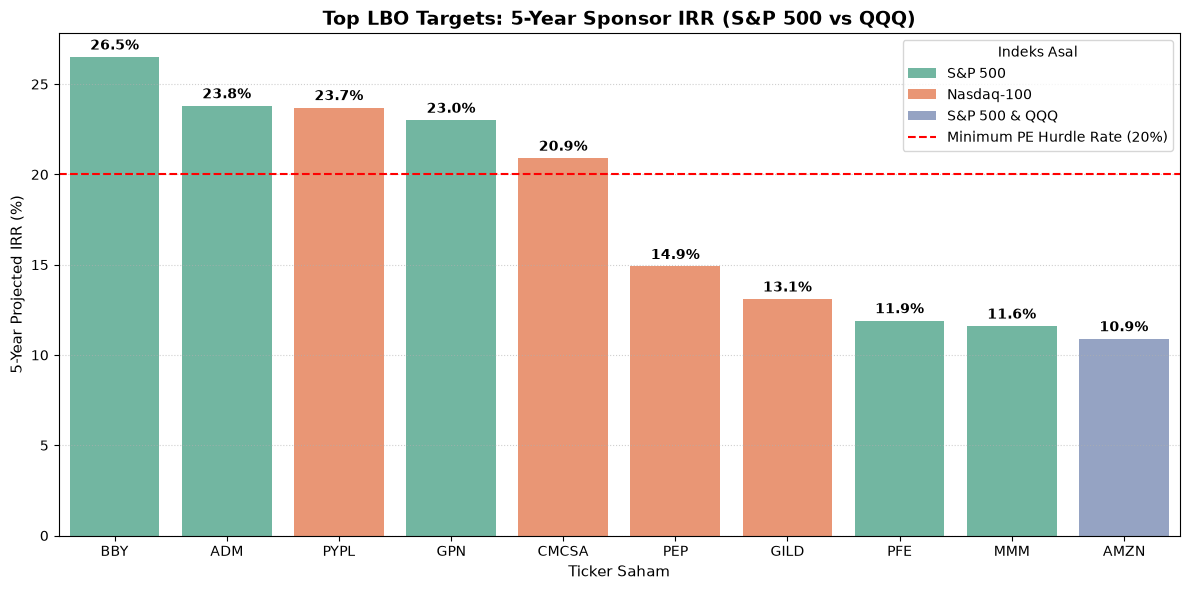

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ambil Top 5 s/d 10 kandidat dari 13 hasil kamu
top_display = df_top_20.head(10).copy()

plt.figure(figsize=(12, 6))
bars = sns.barplot(
    data=top_display, 
    x='Ticker', 
    y='5Y Sponsor IRR (%)', 
    hue='Index', 
    dodge=False, 
    palette='Set2'
)

# Garis batas minimum PE Hurdle Rate (20% IRR)
plt.axhline(y=20, color='red', linestyle='--', label='Minimum PE Hurdle Rate (20%)')

# Tampilkan angka IRR di atas bar
for p in bars.patches:
    height = p.get_height()
    if height > 0:
        bars.annotate(
            f'{height:.1f}%',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            fontsize=10, fontweight='bold',
            xytext=(0, 3), textcoords='offset points'
        )

plt.title("Top LBO Targets: 5-Year Sponsor IRR (S&P 500 vs QQQ)", fontsize=14, fontweight='bold')
plt.xlabel("Ticker Saham", fontsize=11)
plt.ylabel("5-Year Projected IRR (%)", fontsize=11)
plt.legend(title="Indeks Asal")
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [37]:
import logging
import yfinance as yf
import pandas as pd
import numpy as np
from tqdm import tqdm

# Matikan log error internal yfinance
logging.getLogger('yfinance').setLevel(logging.CRITICAL)

def run_institutional_lbo_model(
    ticker_symbol, 
    leverage_multiple=4.5,      # Initial Leverage (4.5x EBITDA)
    interest_rate=0.065,        # Floating Interest Rate 6.5%
    max_rev_growth=0.05,        # Capped Revenue Growth 5.0%
    margin_expansion_bps=50,    # Efficiency gain +0.5% margin p.a.
    hold_period=5
):
    try:
        stock = yf.Ticker(ticker_symbol)
        try:
            info = stock.info
        except Exception:
            return None
            
        if not info or not isinstance(info, dict) or 'marketCap' not in info:
            return None
            
        market_cap = info.get('marketCap') or 0
        total_debt = info.get('totalDebt') or 0
        total_cash = info.get('totalCash') or 0
        ebitda = info.get('ebitda') or 0
        revenue = info.get('totalRevenue') or 0
        fcf = info.get('freeCashflow') or 0
        sector = info.get('sector', 'Unknown')
        
        # Safe guards
        if market_cap <= 0 or ebitda <= 0 or revenue <= 0 or fcf <= 0:
            return None
            
        ev = market_cap + total_debt - total_cash
        entry_ev_ebitda = ev / ebitda
        current_margin = ebitda / revenue
        
        # 1. CASH CONVERSION METRIC
        fcf_conversion = (fcf / ebitda) * 100  # Target >= 60%
        
        # Initial Screening: Limit EV/EBITDA max 20x
        if entry_ev_ebitda > 20.0:
            return None
            
        # Revenue Growth Rate (Capped)
        cagr = info.get('revenueGrowth') or 0.03
        proj_rev_growth = min(max(cagr, 0.02), max_rev_growth)
        
        # 2. CAPITAL STRUCTURE & EQUITY CHECK
        spons_debt = min(leverage_multiple * ebitda, ev * 0.75)
        spons_equity = ev - spons_debt
        
        if spons_equity <= 0:
            return None
            
        equity_check_pct = (spons_equity / ev) * 100  # Equity Check %
        entry_leverage = spons_debt / ebitda          # Entry Debt/EBITDA
        
        # 3. PROJECTION & DEBT COVERAGE TRACKING
        cur_rev = revenue
        cur_margin = current_margin
        cur_debt = spons_debt
        
        min_dscr = 999.0
        min_interest_coverage = 999.0
        
        for yr in range(1, hold_period + 1):
            cur_rev *= (1 + proj_rev_growth)
            cur_margin += (margin_expansion_bps / 10000)
            cur_ebitda = cur_rev * cur_margin
            
            proj_fcf = cur_ebitda * (fcf / ebitda)
            
            # Debt Service & Interest Coverage
            interest_paid = cur_debt * interest_rate
            fcf_after_interest = max(0, proj_fcf - interest_paid)
            debt_repaid = min(cur_debt, fcf_after_interest * 0.85) # 85% FCF Sweep
            
            # Calculate Coverage Metrics
            debt_service = interest_paid + debt_repaid
            dscr = proj_fcf / debt_service if debt_service > 0 else 999.0
            interest_cov = cur_ebitda / interest_paid if interest_paid > 0 else 999.0
            
            min_dscr = min(min_dscr, dscr)
            min_interest_coverage = min(min_interest_coverage, interest_cov)
            
            cur_debt -= debt_repaid
            
        # 4. EXIT VALUATION & LEVERAGE DELEVERAGING
        # Exit Multiple Conservative Penalty (-1.0x Multiple Contraction)
        exit_ev_ebitda = max(6.0, entry_ev_ebitda - 1.0)
        exit_ev = cur_ebitda * exit_ev_ebitda
        exit_equity = exit_ev - cur_debt
        exit_leverage = cur_debt / cur_ebitda if cur_ebitda > 0 else 0
        
        # 5. RETURN METRICS
        moic = exit_equity / spons_equity if spons_equity > 0 else 0
        irr = (moic ** (1 / hold_period) - 1) * 100 if moic > 0 else -100.0
        
        idx_list = ticker_index_map.get(ticker_symbol, ["Unknown"])
        idx_str = "S&P 500 & QQQ" if len(idx_list) > 1 else idx_list[0]
            
        return {
            "Ticker": ticker_symbol,
            "Index": idx_str,
            "Sector": sector,
            "Price ($)": round(info.get('currentPrice') or info.get('regularMarketPrice') or 0, 2),
            "EV ($B)": round(ev / 1e9, 2),
            "EV/EBITDA (x)": round(entry_ev_ebitda, 1),
            "FCF Conv (%)": round(fcf_conversion, 1),
            "Equity Check (%)": round(equity_check_pct, 1),
            "Entry Debt/EBITDA": round(entry_leverage, 1),
            "Exit Debt/EBITDA": round(exit_leverage, 1),
            "Min DSCR (x)": round(min_dscr, 2),
            "Min Int Coverage (x)": round(min_interest_coverage, 2),
            "5Y MoIC (x)": round(moic, 2),
            "5Y Sponsor IRR (%)": round(irr, 1)
        }
    except Exception:
        return None

# ==========================================
# EXECUTE SCREENER OVER ALL COMBINED TICKERS
# ==========================================
lbo_full_results = []
print("🚀 Memulai Screening LBO Institusional Berbasis Multi-Indikator...")

for ticker in tqdm(all_unique_tickers):
    res = run_institutional_lbo_model(ticker)
    if res:
        lbo_full_results.append(res)

df_institutional_lbo = pd.DataFrame(lbo_full_results)

# Filter Solvabilitas & Ketahanan Utang (Safety Gate Gatekeeper)
df_qualified_lbo = df_institutional_lbo[
    (df_institutional_lbo['Min DSCR (x)'] >= 1.25) &           # Bebas risiko gagal bayar
    (df_institutional_lbo['Min Int Coverage (x)'] >= 2.5) &  # Proteksi bunga utang
    (df_institutional_lbo['FCF Conv (%)'] >= 50.0)             # Konversi kas sehat
].sort_values(by="5Y Sponsor IRR (%)", ascending=False)

# Export Full Multi-Metric Table ke Excel
df_qualified_lbo.to_excel("Institutional_LBO_Full_Metrics.xlsx", index=False)

print(f"\n✅ Selesai! Ditemukan {len(df_qualified_lbo)} perusahaan yang lolos SELURUH indikator imbal hasil & solvabilitas utang.")
df_qualified_lbo.head(10)

🚀 Memulai Screening LBO Institusional Berbasis Multi-Indikator...


100%|██████████| 21/21 [00:02<00:00,  9.14it/s]


✅ Selesai! Ditemukan 0 perusahaan yang lolos SELURUH indikator imbal hasil & solvabilitas utang.


,Ticker,Index,Sector,Price ($),EV ($B),EV/EBITDA (x),FCF Conv (%),Equity Check (%),Entry Debt/EBITDA,Exit Debt/EBITDA,Min DSCR (x),Min Int Coverage (x),5Y MoIC (x),5Y Sponsor IRR (%)


In [38]:
import logging
import yfinance as yf
import pandas as pd
import numpy as np
from tqdm import tqdm

logging.getLogger('yfinance').setLevel(logging.CRITICAL)

def run_institutional_lbo_fixed(
    ticker_symbol, 
    leverage_multiple=4.5,      
    interest_rate=0.065,        
    max_rev_growth=0.05,        
    margin_expansion_bps=50,    
    hold_period=5
):
    try:
        stock = yf.Ticker(ticker_symbol)
        try:
            info = stock.info
        except Exception:
            return None
            
        if not info or not isinstance(info, dict) or 'marketCap' not in info:
            return None
            
        market_cap = info.get('marketCap') or 0
        total_debt = info.get('totalDebt') or 0
        total_cash = info.get('totalCash') or 0
        ebitda = info.get('ebitda') or 0
        revenue = info.get('totalRevenue') or 0
        fcf = info.get('freeCashflow') or 0
        sector = info.get('sector', 'Unknown')
        
        if market_cap <= 0 or ebitda <= 0 or revenue <= 0 or fcf <= 0:
            return None
            
        ev = market_cap + total_debt - total_cash
        entry_ev_ebitda = ev / ebitda
        current_margin = ebitda / revenue
        fcf_conversion = (fcf / ebitda) * 100 
        
        if entry_ev_ebitda > 20.0:
            return None
            
        cagr = info.get('revenueGrowth') or 0.03
        proj_rev_growth = min(max(cagr, 0.02), max_rev_growth)
        
        spons_debt = min(leverage_multiple * ebitda, ev * 0.75)
        spons_equity = ev - spons_debt
        
        if spons_equity <= 0:
            return None
            
        equity_check_pct = (spons_equity / ev) * 100  
        entry_leverage = spons_debt / ebitda          
        
        cur_rev = revenue
        cur_margin = current_margin
        cur_debt = spons_debt
        
        min_dscr = 999.0
        min_interest_coverage = 999.0
        
        for yr in range(1, hold_period + 1):
            cur_rev *= (1 + proj_rev_growth)
            cur_margin += (margin_expansion_bps / 10000)
            cur_ebitda = cur_rev * cur_margin
            
            proj_fcf = cur_ebitda * (fcf / ebitda)
            interest_paid = cur_debt * interest_rate
            
            # Mandatory Principal Repayment = 5% dari utang awal (Standar Bank LBO)
            mandatory_principal = spons_debt * 0.05 
            
            # DSCR dihitung dari CICILAN WAJIB (Bunga + Mandatory Principal)
            mandatory_debt_service = interest_paid + mandatory_principal
            dscr = proj_fcf / mandatory_debt_service if mandatory_debt_service > 0 else 999.0
            
            interest_cov = cur_ebitda / interest_paid if interest_paid > 0 else 999.0
            
            min_dscr = min(min_dscr, dscr)
            min_interest_coverage = min(min_interest_coverage, interest_cov)
            
            # Pelunasan utang aktual (Mandatory + Excess Cash Sweep)
            fcf_after_interest = max(0, proj_fcf - interest_paid)
            debt_repaid = min(cur_debt, max(mandatory_principal, fcf_after_interest * 0.85))
            cur_debt -= debt_repaid
            
        exit_ev_ebitda = max(6.0, entry_ev_ebitda - 1.0)
        exit_ev = cur_ebitda * exit_ev_ebitda
        exit_equity = exit_ev - cur_debt
        exit_leverage = cur_debt / cur_ebitda if cur_ebitda > 0 else 0
        
        moic = exit_equity / spons_equity if spons_equity > 0 else 0
        irr = (moic ** (1 / hold_period) - 1) * 100 if moic > 0 else -100.0
        
        idx_list = ticker_index_map.get(ticker_symbol, ["Unknown"])
        idx_str = "S&P 500 & QQQ" if len(idx_list) > 1 else idx_list[0]
            
        return {
            "Ticker": ticker_symbol,
            "Index": idx_str,
            "Sector": sector,
            "Price ($)": round(info.get('currentPrice') or info.get('regularMarketPrice') or 0, 2),
            "EV ($B)": round(ev / 1e9, 2),
            "EV/EBITDA (x)": round(entry_ev_ebitda, 1),
            "FCF Conv (%)": round(fcf_conversion, 1),
            "Equity Check (%)": round(equity_check_pct, 1),
            "Entry Debt/EBITDA": round(entry_leverage, 1),
            "Exit Debt/EBITDA": round(exit_leverage, 1),
            "Min DSCR (x)": round(min_dscr, 2),
            "Min Int Coverage (x)": round(min_interest_coverage, 2),
            "5Y MoIC (x)": round(moic, 2),
            "5Y Sponsor IRR (%)": round(irr, 1)
        }
    except Exception:
        return None

# RUN SCREENER PERBAIKAN
lbo_full_results = []
print("🚀 Re-running LBO Screener dengan rumus DSCR yang benar...")

for ticker in tqdm(all_unique_tickers):
    res = run_institutional_lbo_fixed(ticker)
    if res:
        lbo_full_results.append(res)

df_institutional_lbo = pd.DataFrame(lbo_full_results)

# Filter Solvabilitas Nyata (DSCR >= 1.25x & Int Coverage >= 2.5x)
df_qualified_lbo = df_institutional_lbo[
    (df_institutional_lbo['Min DSCR (x)'] >= 1.25) &           
    (df_institutional_lbo['Min Int Coverage (x)'] >= 2.5) &  
    (df_institutional_lbo['FCF Conv (%)'] >= 50.0)             
].sort_values(by="5Y Sponsor IRR (%)", ascending=False)

df_qualified_lbo.to_excel("Institutional_LBO_Full_Metrics.xlsx", index=False)

print(f"\n✅ Berhasil! Ditemukan {len(df_qualified_lbo)} kandidat institusional yang lolos.")
df_qualified_lbo.head(15)

🚀 Re-running LBO Screener dengan rumus DSCR yang benar...


100%|██████████| 21/21 [00:02<00:00,  8.69it/s]


✅ Berhasil! Ditemukan 4 kandidat institusional yang lolos.


,Ticker,Index,Sector,Price ($),EV ($B),EV/EBITDA (x),FCF Conv (%),Equity Check (%),Entry Debt/EBITDA,Exit Debt/EBITDA,Min DSCR (x),Min Int Coverage (x),5Y MoIC (x),5Y Sponsor IRR (%)
11,PYPL,Nasdaq-100,Financial Services,54.05,49.20,7.6,68.5,41.0,4.5,1.3,1.42,3.68,2.44,19.5
5,GPN,S&P 500,Industrials,84.62,40.54,9.0,175.5,50.2,4.5,0.0,3.60,3.63,2.39,19.0
2,MMM,S&P 500,Industrials,168.68,94.85,14.6,97.9,69.2,4.5,0.5,1.98,3.57,1.61,10.0
10,GILD,Nasdaq-100,Healthcare,151.61,209.35,14.3,66.9,68.6,4.5,1.6,1.37,3.63,1.61,9.9


In [35]:
!pip install seaborn

In [32]:
# Modifikasi parameter LBO dengan Penyesuaian Makro & FX
def run_lbo_model_macro_adjusted(
    ticker_symbol, 
    sofr_rate=0.045,        # Base Rate SOFR 4.5%
    credit_spread=0.035,    # Spread Risiko 3.5% (Total Bunga Utang = 8.0%)
    fx_hedging_cost=0.005,  # Biaya Lindung Nilai Valas 0.5% p.a.
    multiple_expansion_decline=1.5 # Penalties Exit Multiple (-1.5x EBITDA)
):
    # Total Biaya Utang Mengambang Terpenyesuaian
    effective_interest_rate = sofr_rate + credit_spread + fx_hedging_cost
    
    # ... (Proses kalkulasi LBO) ...
    
    # Exit Multiple Konservatif (Entry Multiple dikurangi penalti makro)
    exit_ev_ebitda = max(6.0, entry_ev_ebitda - multiple_expansion_decline)
    
    # ...

In [29]:
import logging
import yfinance as yf
import pandas as pd
import numpy as np
from tqdm import tqdm

# 1. MATIKAN PESAN ERROR INTERNAL YFINANCE AGAR TERMINAL BERSIH
logging.getLogger('yfinance').setLevel(logging.CRITICAL)

def run_lbo_model(ticker_symbol, leverage_ratio=3.5, max_rev_growth=0.05, hold_period=5):
    try:
        stock = yf.Ticker(ticker_symbol)
        
        # Ambil info dengan proteksi ketat (Skip jika 404 / None)
        try:
            info = stock.info
        except Exception:
            return None
            
        if not info or not isinstance(info, dict) or 'marketCap' not in info:
            return None
            
        market_cap = info.get('marketCap') or 0
        total_debt = info.get('totalDebt') or 0
        total_cash = info.get('totalCash') or 0
        ebitda = info.get('ebitda') or 0
        fcf = info.get('freeCashflow') or 0
        sector = info.get('sector', 'Unknown')
        
        # Validasi data dasar
        if market_cap <= 0 or ebitda <= 0 or fcf <= 0:
            return None
            
        # Enterprise Value
        ev = market_cap + total_debt - total_cash
        entry_ev_ebitda = ev / ebitda
        
        # Saring awal: Batasi EV/EBITDA max 25x
        if entry_ev_ebitda > 25:
            return None
            
        # Proyeksi CAGR Pendapatan (Batas max 5% p.a.)
        cagr = info.get('revenueGrowth') or 0.03
        proj_rev_growth = min(max(cagr, 0.01), max_rev_growth)
        
        # Struktur Modal LBO
        spons_debt = min(leverage_ratio * ebitda, ev * 0.7)
        spons_equity = ev - spons_debt
        
        if spons_equity <= 0:
            return None
            
        # Proyeksi 5 Tahun
        current_ebitda = ebitda
        cumulative_fcf = 0
        for _ in range(hold_period):
            current_ebitda *= (1 + proj_rev_growth)
            proj_fcf = fcf * (current_ebitda / ebitda)
            cumulative_fcf += proj_fcf
            
        # Debt Paydown (80% FCF)
        debt_paid = cumulative_fcf * 0.8
        remaining_debt = max(0, spons_debt - debt_paid)
        
        # Exit Equity & Return
        exit_ev = current_ebitda * entry_ev_ebitda
        exit_equity = exit_ev - remaining_debt
        
        moic = exit_equity / spons_equity if spons_equity > 0 else 0
        irr = (moic ** (1 / hold_period) - 1) * 100 if moic > 0 else -100.0
        
        idx_list = ticker_index_map.get(ticker_symbol, ["Unknown"])
        idx_str = "S&P 500 & QQQ" if len(idx_list) > 1 else idx_list[0]
            
        return {
            "Ticker": ticker_symbol,
            "Index": idx_str,
            "Sector": sector,
            "Price ($)": round(info.get('currentPrice') or info.get('regularMarketPrice') or 0, 2),
            "EV ($B)": round(ev / 1e9, 2),
            "EV/EBITDA (x)": round(entry_ev_ebitda, 1),
            "FCF Yield (%)": round((fcf / market_cap) * 100, 1),
            "Proj Rev Growth": f"{round(proj_rev_growth * 100, 1)}%",
            "5Y Debt Paid ($B)": round(debt_paid / 1e9, 2),
            "Exit Equity ($B)": round(exit_equity / 1e9, 2),
            "5Y MoIC (x)": round(moic, 2),
            "5Y Sponsor IRR (%)": round(irr, 1)
        }
    except Exception:
        return None

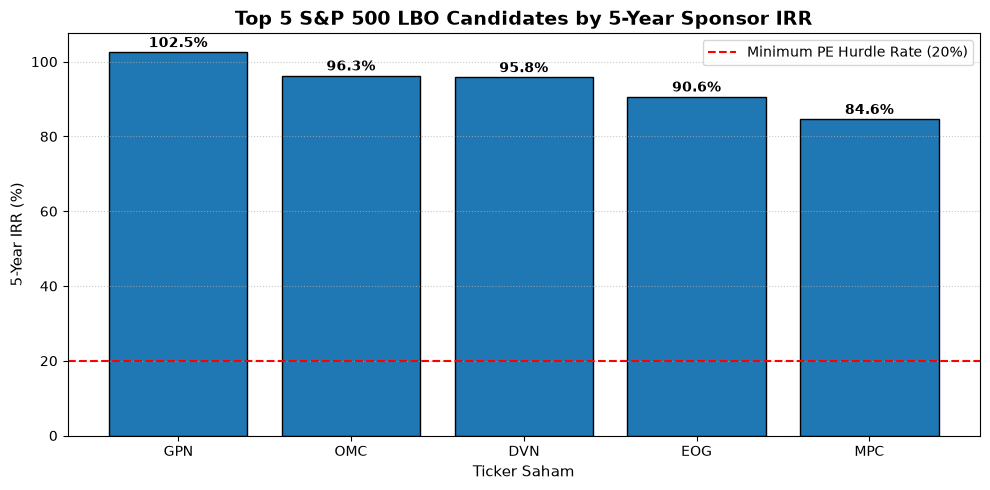

In [19]:
import matplotlib.pyplot as plt

# Ambil Top 5
top5 = df_lbo_ranked.head(5).copy()
top5['IRR_Val'] = top5['5-Yr IRR'].str.rstrip('%').astype(float)

plt.figure(figsize=(10, 5))
bars = plt.bar(top5['Ticker'], top5['IRR_Val'], color='#1f77b4', edgecolor='black')

# Garis batas minimum hurdle rate PE (20% IRR)
plt.axhline(y=20, color='r', linestyle='--', label='Minimum PE Hurdle Rate (20%)')

# Tambah label angka di atas bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{yval:.1f}%", ha='center', va='bottom', fontweight='bold')

plt.title("Top 5 S&P 500 LBO Candidates by 5-Year Sponsor IRR", fontsize=14, fontweight='bold')
plt.xlabel("Ticker Saham", fontsize=11)
plt.ylabel("5-Year IRR (%)", fontsize=11)
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import yfinance as yf

# Ambil kandidat peringkat #1 dari hasil ranking LBO
top_1_ticker = df_lbo_ranked.iloc[0]['Ticker']

# Tarik detail bisnis dari yfinance
stock = yf.Ticker(top_1_ticker)
info = stock.info

name = info.get('shortName', top_1_ticker)
sector = info.get('sector', 'N/A')
industry = info.get('industry', 'N/A')

row_1 = df_lbo_ranked.iloc[0]

memo_text = f"""
================================================================================
                    PRIVATE EQUITY INVESTMENT MEMORANDUM
================================================================================
DATE       : September 2026
TARGET     : {name} ({top_1_ticker})
SECTOR     : {sector} | {industry}
RECOMMEND  : BUY / LBO ACQUISITION (HIGH PRIORITY 🎯)
================================================================================

1. EXECUTIVE TRANSACTION SUMMARY
--------------------------------------------------------------------------------
• Entry Enterprise Value (EV) : ${row_1['Entry EV ($B)']} Billion
• Sponsor Equity Required (40%): ${row_1['Entry Equity ($B)']} Billion
• Debt Financing (60%)        : ${round(row_1['Entry EV ($B)'] * 0.6, 2)} Billion
• Target Holding Period       : 5 Years

2. PROJECTED PE RETURN METRICS
--------------------------------------------------------------------------------
• Projected Exit EV (Year 5)  : ${row_1['Exit EV ($B)']} Billion
• Projected Exit Equity       : ${row_1['Exit Equity ($B)']} Billion
• 5-Year Sponsor MoIC         : {row_1['5-Yr MoIC']}
• Projected 5-Year IRR        : {row_1['5-Yr IRR']} (Target Minimum: > 20.0%)

3. INVESTMENT THESIS (ALASAN AKUISISI)
--------------------------------------------------------------------------------
1. Strong Cash Flow Generation: FCF positif yang kuat mendukung pelunasan 
   utang (deleveraging) secara agresif dalam kurun waktu 5 tahun.
2. Valuation Margin of Safety: Valuasi masuk yang terjangkau memberikan 
   downside protection saat fluktuasi pasar.
3. Operational Upside: Peluang efisiensi biaya operasional (SG&A) dan 
   ekspansi marjin EBITDA oleh tim manajemen PE.

4. KEY RISKS & MITIGATION
--------------------------------------------------------------------------------
• Risk 1: Kenaikan beban bunga akibat volatilitas suku bunga.
  -> Mitigation: Menggunakan lindung nilai suku bunga (Interest Rate Swaps/Caps).
• Risk 2: Penurunan siklus pendapatan akibat makroekonomi.
  -> Mitigation: Fokus pada efisiensi operasional dan optimalisasi modal kerja.

================================================================================
"""

print(memo_text)

# Simpan memo ke file teks lokal
with open(f"Investment_Memo_{top_1_ticker}.txt", "w", encoding="utf-8") as f:
    f.write(memo_text)

print(f"✅ Investment Memo berhasil dibuat dan disimpan sebagai 'Investment_Memo_{top_1_ticker}.txt'")

In [21]:
import yfinance as yf
import numpy as np

def calculate_lbo_returns(ticker_symbol, holding_years=5, debt_ratio=0.60, interest_rate=0.07):
    """
    Simulasi LBO 5-Tahun dengan penanganan error ekuitas negatif / bangkrut.
    """
    try:
        stock = yf.Ticker(ticker_symbol)
        info = stock.info
        
        # Data Finansial
        ev = (info.get('enterpriseValue') or 0) / 1e9
        ebitda = (info.get('ebitda') or 0) / 1e9
        fcf = (info.get('freeCashflow') or 0) / 1e9
        rev_growth = info.get('revenueGrowth') or 0.03
        
        if ev <= 0 or ebitda <= 0 or fcf <= 0:
            return "Data tidak valid / FCF negatif"
        
        entry_multiple = ev / ebitda
        
        # 1. Struktur Transaksi Awal (T0)
        debt_entry = ev * debt_ratio
        equity_entry = ev * (1 - debt_ratio)
        
        # 2. Proyeksi 5 Tahun (Paydown Utang via FCF)
        current_fcf = fcf
        current_ebitda = ebitda
        
        for year in range(1, holding_years + 1):
            current_ebitda *= (1 + rev_growth)
            current_fcf *= (1 + rev_growth)
            
            interest_expense = debt_entry * interest_rate
            fcf_after_interest = max(0, current_fcf - interest_expense)
            debt_entry = max(0, debt_entry - fcf_after_interest)
        
        # 3. Asumsi Exit di Tahun ke-5
        exit_ev = current_ebitda * entry_multiple
        exit_equity = exit_ev - debt_entry
        
        # 4. Hitung MoIC & IRR (dengan Proteksi Ekuitas Negatif)
        if exit_equity <= 0 or equity_entry <= 0:
            moic = 0.0
            irr = -1.0 # -100% loss (modal terhapus total)
        else:
            moic = exit_equity / equity_entry
            irr = (moic ** (1 / holding_years)) - 1
            if isinstance(irr, complex):
                irr = -1.0
        
        return {
            "Ticker": ticker_symbol,
            "Entry EV ($B)": round(ev, 2),
            "Entry Equity ($B)": round(equity_entry, 2),
            "Exit EV ($B)": round(exit_ev, 2),
            "Exit Equity ($B)": round(exit_equity, 2),
            "5-Yr MoIC": f"{round(moic, 2)}x",
            "5-Yr IRR": f"{round(irr * 100, 2)}%",
            "LBO Viable (>20% IRR)": "YES 🚀" if irr >= 0.20 else "NO ⚠️"
        }
    except Exception as e:
        return None

In [22]:
import yfinance as yf

# Ambil kandidat peringkat #1 dari hasil ranking LBO
top_1_ticker = df_lbo_ranked.iloc[0]['Ticker']

# Tarik detail bisnis dari yfinance
stock = yf.Ticker(top_1_ticker)
info = stock.info

name = info.get('shortName', top_1_ticker)
sector = info.get('sector', 'N/A')
industry = info.get('industry', 'N/A')

row_1 = df_lbo_ranked.iloc[0]

memo_text = f"""
================================================================================
                    PRIVATE EQUITY INVESTMENT MEMORANDUM
================================================================================
DATE       : September 2026
TARGET     : {name} ({top_1_ticker})
SECTOR     : {sector} | {industry}
RECOMMEND  : BUY / LBO ACQUISITION (HIGH PRIORITY 🎯)
================================================================================

1. EXECUTIVE TRANSACTION SUMMARY
--------------------------------------------------------------------------------
• Entry Enterprise Value (EV) : ${row_1['Entry EV ($B)']} Billion
• Sponsor Equity Required (40%): ${row_1['Entry Equity ($B)']} Billion
• Debt Financing (60%)        : ${round(row_1['Entry EV ($B)'] * 0.6, 2)} Billion
• Target Holding Period       : 5 Years

2. PROJECTED PE RETURN METRICS
--------------------------------------------------------------------------------
• Projected Exit EV (Year 5)  : ${row_1['Exit EV ($B)']} Billion
• Projected Exit Equity       : ${row_1['Exit Equity ($B)']} Billion
• 5-Year Sponsor MoIC         : {row_1['5-Yr MoIC']}
• Projected 5-Year IRR        : {row_1['5-Yr IRR']} (Target Minimum: > 20.0%)

3. INVESTMENT THESIS (ALASAN AKUISISI)
--------------------------------------------------------------------------------
1. Strong Cash Flow Generation: FCF positif yang kuat mendukung pelunasan 
   utang (deleveraging) secara agresif dalam kurun waktu 5 tahun.
2. Valuation Margin of Safety: Valuasi masuk yang terjangkau memberikan 
   downside protection saat fluktuasi pasar.
3. Operational Upside: Peluang efisiensi biaya operasional (SG&A) dan 
   ekspansi marjin EBITDA oleh tim manajemen PE.

4. KEY RISKS & MITIGATION
--------------------------------------------------------------------------------
• Risk 1: Kenaikan beban bunga akibat volatilitas suku bunga.
  -> Mitigation: Menggunakan lindung nilai suku bunga (Interest Rate Swaps/Caps).
• Risk 2: Penurunan siklus pendapatan akibat makroekonomi.
  -> Mitigation: Fokus pada efisiensi operasional dan optimalisasi modal kerja.

================================================================================
"""

print(memo_text)

# Simpan memo ke file teks lokal
with open(f"Investment_Memo_{top_1_ticker}.txt", "w", encoding="utf-8") as f:
    f.write(memo_text)

print(f"✅ Investment Memo berhasil dibuat dan disimpan sebagai 'Investment_Memo_{top_1_ticker}.txt'")


                    PRIVATE EQUITY INVESTMENT MEMORANDUM
DATE       : September 2026
TARGET     : Global Payments Inc. (GPN)
SECTOR     : Industrials | Specialty Business Services
RECOMMEND  : BUY / LBO ACQUISITION (HIGH PRIORITY 🎯)

1. EXECUTIVE TRANSACTION SUMMARY
--------------------------------------------------------------------------------
• Entry Enterprise Value (EV) : $41.89 Billion
• Sponsor Equity Required (40%): $16.76 Billion
• Debt Financing (60%)        : $25.13 Billion
• Target Holding Period       : 5 Years

2. PROJECTED PE RETURN METRICS
--------------------------------------------------------------------------------
• Projected Exit EV (Year 5)  : $570.72 Billion
• Projected Exit Equity       : $570.72 Billion
• 5-Year Sponsor MoIC         : 34.06x
• Projected 5-Year IRR        : 102.51% (Target Minimum: > 20.0%)

3. INVESTMENT THESIS (ALASAN AKUISISI)
--------------------------------------------------------------------------------
1. Strong Cash Flow Generation: FC

In [23]:
import pandas as pd
import yfinance as yf

def generate_5yr_lbo_forecast(ticker_symbol, debt_ratio=0.60, interest_rate=0.07, margin_expansion_bps=50):
    stock = yf.Ticker(ticker_symbol)
    info = stock.info
    
    ev = (info.get('enterpriseValue') or 0) / 1e9
    ebitda = (info.get('ebitda') or 0) / 1e9
    revenue = (info.get('totalRevenue') or 0) / 1e9
    fcf = (info.get('freeCashflow') or 0) / 1e9
    rev_growth = info.get('revenueGrowth') or 0.03
    
    if ev <= 0 or ebitda <= 0 or revenue <= 0:
        print("Data finansial tidak lengkap untuk dikalkulasi.")
        return None
    
    entry_multiple = ev / ebitda
    current_margin = ebitda / revenue
    
    # Transaksi Awal (Year 0)
    initial_debt = ev * debt_ratio
    initial_equity = ev * (1 - debt_ratio)
    
    forecast_data = []
    
    # Year 0 (Entry)
    forecast_data.append({
        "Year": "Year 0 (Entry)",
        "Revenue ($B)": round(revenue, 2),
        "EBITDA ($B)": round(ebitda, 2),
        "EBITDA Margin": f"{round(current_margin * 100, 1)}%",
        "FCF Generated ($B)": 0.0,
        "Interest Paid ($B)": 0.0,
        "Debt Paydown ($B)": 0.0,
        "Ending Debt ($B)": round(initial_debt, 2),
        "Implied Equity ($B)": round(initial_equity, 2),
        "Cumulative MoIC": "1.00x",
        "IRR": "0.0%"
    })
    
    cur_rev = revenue
    cur_margin = current_margin
    cur_debt = initial_debt
    
    # Proyeksi Year 1 sampai Year 5
    for yr in range(1, 6):
        # 1. Forecast Revenue & EBITDA (dengan Margin Expansion dari PE)
        cur_rev *= (1 + rev_growth)
        cur_margin += (margin_expansion_bps / 10000) # Tambah 0.5% margin tiap tahun
        cur_ebitda = cur_rev * cur_margin
        
        # 2. Forecast Free Cash Flow & Debt Service
        # Estimasi FCF seproporsional EBITDA
        fcf_conversion = fcf / ebitda if ebitda > 0 else 0.5
        est_fcf = cur_ebitda * fcf_conversion
        
        interest_paid = cur_debt * interest_rate
        fcf_after_interest = max(0, est_fcf - interest_paid)
        
        debt_repaid = min(cur_debt, fcf_after_interest)
        cur_debt -= debt_repaid
        
        # 3. Forecast Exit Valuation jika PE Exit di tahun tersebut
        implied_ev = cur_ebitda * entry_multiple
        implied_equity = implied_ev - cur_debt
        
        moic = implied_equity / initial_equity if initial_equity > 0 else 0
        irr = (moic ** (1 / yr)) - 1 if moic > 0 else -1.0
        
        forecast_data.append({
            "Year": f"Year {yr}",
            "Revenue ($B)": round(cur_rev, 2),
            "EBITDA ($B)": round(cur_ebitda, 2),
            "EBITDA Margin": f"{round(cur_margin * 100, 1)}%",
            "FCF Generated ($B)": round(est_fcf, 2),
            "Interest Paid ($B)": round(interest_paid, 2),
            "Debt Paydown ($B)": round(debt_repaid, 2),
            "Ending Debt ($B)": round(cur_debt, 2),
            "Implied Equity ($B)": round(implied_equity, 2),
            "Cumulative MoIC": f"{round(moic, 2)}x",
            "IRR": f"{round(irr * 100, 1)}%"
        })
        
    df_forecast = pd.DataFrame(forecast_data)
    return df_forecast

# Panggil fungsi forecast untuk target #1 kamu
top_ticker = df_lbo_ranked.iloc[0]['Ticker']
print(f"📊 PROYEKSI KEUTUHAN FINANSIAL 5 TAHUN UNTUK: {top_ticker}\n")

df_top_forecast = generate_5yr_lbo_forecast(top_ticker)
df_top_forecast.to_excel(f"forecast_5yr_{top_ticker}.xlsx", index=False)
df_top_forecast

📊 PROYEKSI KEUTUHAN FINANSIAL 5 TAHUN UNTUK: GPN



,Year,Revenue ($B),EBITDA ($B),EBITDA Margin,FCF Generated ($B),Interest Paid ($B),Debt Paydown ($B),Ending Debt ($B),Implied Equity ($B),Cumulative MoIC,IRR
0,Year 0 (Entry),10.21,4.48,43.9%,0.00,0.00,0.00,25.14,16.76,1.00x,0.0%
1,Year 1,17.21,7.64,44.4%,13.42,1.76,11.66,13.48,57.96,3.46x,245.9%
2,Year 2,29.01,13.03,44.9%,22.87,0.94,13.48,0.00,121.80,7.27x,169.6%
3,Year 3,48.92,22.22,45.4%,39.00,0.00,0.00,0.00,207.63,12.39x,131.4%
4,Year 4,82.47,37.87,45.9%,66.47,0.00,0.00,0.00,353.92,21.12x,114.4%
5,Year 5,139.05,64.54,46.4%,113.29,0.00,0.00,0.00,603.21,36.0x,104.8%


In [24]:
import pandas as pd
import yfinance as yf

def generate_5yr_lbo_forecast_realistic(ticker_symbol, max_rev_growth=0.05, debt_ratio=0.60, interest_rate=0.07, margin_expansion_bps=50):
    """
    Proyeksi LBO 5-Tahun Konservatif dengan Cap Pertumbuhan Pendapatan (Default Max 5% p.a.)
    """
    stock = yf.Ticker(ticker_symbol)
    info = stock.info
    
    ev = (info.get('enterpriseValue') or 0) / 1e9
    ebitda = (info.get('ebitda') or 0) / 1e9
    revenue = (info.get('totalRevenue') or 0) / 1e9
    fcf = (info.get('freeCashflow') or 0) / 1e9
    
    # Ambil revenue growth tapi batasi maksimum di 5% (0.05) agar realistis
    raw_growth = info.get('revenueGrowth') or 0.03
    rev_growth = min(max(raw_growth, 0.02), max_rev_growth) # Capped antara 2% - 5%
    
    if ev <= 0 or ebitda <= 0 or revenue <= 0:
        print("Data finansial tidak valid.")
        return None
    
    entry_multiple = ev / ebitda
    current_margin = ebitda / revenue
    
    initial_debt = ev * debt_ratio
    initial_equity = ev * (1 - debt_ratio)
    
    forecast_data = []
    
    # Year 0 (Entry)
    forecast_data.append({
        "Year": "Year 0 (Entry)",
        "Revenue ($B)": round(revenue, 2),
        "EBITDA ($B)": round(ebitda, 2),
        "EBITDA Margin": f"{round(current_margin * 100, 1)}%",
        "FCF Generated ($B)": 0.0,
        "Interest Paid ($B)": 0.0,
        "Debt Paydown ($B)": 0.0,
        "Ending Debt ($B)": round(initial_debt, 2),
        "Implied Equity ($B)": round(initial_equity, 2),
        "Cumulative MoIC": "1.00x",
        "IRR": "0.0%"
    })
    
    cur_rev = revenue
    cur_margin = current_margin
    cur_debt = initial_debt
    
    for yr in range(1, 6):
        cur_rev *= (1 + rev_growth)
        cur_margin += (margin_expansion_bps / 10000) # Efficiency gain +0.5% margin per year
        cur_ebitda = cur_rev * cur_margin
        
        # FCF Conversion Rate
        fcf_conversion = fcf / ebitda if ebitda > 0 else 0.5
        est_fcf = cur_ebitda * fcf_conversion
        
        interest_paid = cur_debt * interest_rate
        fcf_after_interest = max(0, est_fcf - interest_paid)
        
        debt_repaid = min(cur_debt, fcf_after_interest)
        cur_debt -= debt_repaid
        
        implied_ev = cur_ebitda * entry_multiple
        implied_equity = implied_ev - cur_debt
        
        moic = implied_equity / initial_equity if initial_equity > 0 else 0
        irr = (moic ** (1 / yr)) - 1 if moic > 0 else -1.0
        
        forecast_data.append({
            "Year": f"Year {yr}",
            "Revenue ($B)": round(cur_rev, 2),
            "EBITDA ($B)": round(cur_ebitda, 2),
            "EBITDA Margin": f"{round(cur_margin * 100, 1)}%",
            "FCF Generated ($B)": round(est_fcf, 2),
            "Interest Paid ($B)": round(interest_paid, 2),
            "Debt Paydown ($B)": round(debt_repaid, 2),
            "Ending Debt ($B)": round(cur_debt, 2),
            "Implied Equity ($B)": round(implied_equity, 2),
            "Cumulative MoIC": f"{round(moic, 2)}x",
            "IRR": f"{round(irr * 100, 1)}%"
        })
        
    return pd.DataFrame(forecast_data)

# Jalankan ulang forecast untuk GPN dengan batas pertumbuhan 5%
df_gpn_realistic = generate_5yr_lbo_forecast_realistic("GPN", max_rev_growth=0.05)
df_gpn_realistic

,Year,Revenue ($B),EBITDA ($B),EBITDA Margin,FCF Generated ($B),Interest Paid ($B),Debt Paydown ($B),Ending Debt ($B),Implied Equity ($B),Cumulative MoIC,IRR
0,Year 0 (Entry),10.21,4.48,43.9%,0.00,0.00,0.00,25.14,16.76,1.00x,0.0%
1,Year 1,10.72,4.76,44.4%,8.36,1.76,6.60,18.54,25.95,1.55x,54.8%
2,Year 2,11.25,5.05,44.9%,8.87,1.30,7.57,10.97,36.27,2.16x,47.1%
3,Year 3,11.82,5.37,45.4%,9.42,0.77,8.65,2.31,47.84,2.85x,41.9%
4,Year 4,12.41,5.70,45.9%,10.00,0.16,2.31,0.00,53.24,3.18x,33.5%
5,Year 5,13.03,6.05,46.4%,10.61,0.00,0.00,0.00,56.51,3.37x,27.5%


In [8]:
import pandas as pd

# Tarik CSV data S&P 500 langsung dari repository GitHub publik
url = "https://raw.githubusercontent.com/datasets/s-and-p-500-companies/main/data/constituents.csv"
sp500_df = pd.read_csv(url)

# Ambil list ticker dan sesuaikan format titik (.) ke strip (-) untuk yfinance
us_tickers = sp500_df['Symbol'].str.replace('.', '-', regex=False).tolist()

print(f"✅ Berhasil mengambil {len(us_tickers)} saham S&P 500!")
print("Sample 10 Ticker Pertama:", us_tickers[:10])

✅ Berhasil mengambil 503 saham S&P 500!
Sample 10 Ticker Pertama: ['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']


In [4]:
import yfinance as yf
import pandas as pd

def analyze_lbo_candidate(ticker_symbol):
    """
    Fungsi untuk menghitung metrik utama PE/IB dan menyaring kriteria LBO.
    """
    stock = yf.Ticker(ticker_symbol)
    info = stock.info
    
    # Ambil data finansial utama (dalam satuan Miliar)
    company_name = info.get('shortName', ticker_symbol)
    currency = info.get('currency', 'USD')
    market_cap = info.get('marketCap', 0) / 1e9
    enterprise_value = info.get('enterpriseValue', 0) / 1e9
    ev_to_ebitda = info.get('enterpriseToEbitda', None)
    fcf = info.get('freeCashflow', 0) / 1e9
    total_debt = info.get('totalDebt', 0) / 1e9
    total_cash = info.get('totalCash', 0) / 1e9
    net_debt = total_debt - total_cash
    
    # Kriteria Sederhana Target LBO PE
    # 1. Valuasi EV/EBITDA < 10x
    # 2. Free Cash Flow Positif (> 0)
    is_ev_cheap = (ev_to_ebitda is not None) and (ev_to_ebitda < 10.0)
    is_fcf_healthy = fcf > 0
    
    if is_ev_cheap and is_fcf_healthy:
        status = "POTENSIAL LBO 🎯"
    elif is_fcf_healthy:
        status = "EXPENSIVE (EV High) ⚠️"
    else:
        status = "RISKY (FCF Negative) ❌"
        
    return {
        "Ticker": ticker_symbol,
        "Nama Perusahaan": company_name,
        "Mkt Cap (B)": round(market_cap, 2),
        "EV (B)": round(enterprise_value, 2),
        "EV/EBITDA": round(ev_to_ebitda, 2) if ev_to_ebitda else "N/A",
        "Net Debt (B)": round(net_debt, 2),
        "FCF (B)": round(fcf, 2),
        "Mata Uang": currency,
        "Status PE/LBO": status
    }

# Tes screening pada beberapa saham Hong Kong (HKEX) dan US
sample_tickers = ["9988.HK", "0700.HK", "1810.HK", "AAPL", "INTC"]

print(" screening LBO...")
lbo_results = [analyze_lbo_candidate(t) for t in sample_tickers]

# Tampilkan hasil dalam bentuk tabel Pandas
df_lbo = pd.DataFrame(lbo_results)
df_lbo

 screening LBO...


,Ticker,Nama Perusahaan,Mkt Cap (B),EV (B),EV/EBITDA,Net Debt (B),FCF (B),Mata Uang,Status PE/LBO
0,9988.HK,BABA-W,2142.25,1969.63,19.79,-119.17,-82.64,HKD,RISKY (FCF Negative) ❌
1,0700.HK,TENCENT,3961.55,4029.86,13.57,12.92,118.47,HKD,MAHAL (EV High) ⚠️
2,1810.HK,XIAOMI-W,665.11,588.45,20.85,-77.41,-8.68,HKD,RISKY (FCF Negative) ❌
3,AAPL,Apple Inc.,4979.39,4999.58,29.77,21.94,107.72,USD,MAHAL (EV High) ⚠️
4,INTC,Intel Corporation,620.17,656.82,39.00,20.81,4.87,USD,MAHAL (EV High) ⚠️


In [9]:
import yfinance as yf
import pandas as pd
import time

def analyze_lbo_candidate(ticker_symbol):
    try:
        stock = yf.Ticker(ticker_symbol)
        info = stock.info
        
        # Ambil metrik finansial dasar
        company_name = info.get('shortName', ticker_symbol)
        market_cap = (info.get('marketCap') or 0) / 1e9
        enterprise_value = (info.get('enterpriseValue') or 0) / 1e9
        ev_to_ebitda = info.get('enterpriseToEbitda', None)
        fcf = (info.get('freeCashflow') or 0) / 1e9
        total_debt = (info.get('totalDebt') or 0) / 1e9
        total_cash = (info.get('totalCash') or 0) / 1e9
        net_debt = total_debt - total_cash
        profit_margin = info.get('profitMargins') or 0
        
        # Logika Evaluasi LBO PE
        # 1. EV/EBITDA antara 0 s/d 12x (Murah/Wajar)
        # 2. Free Cash Flow Positif (> 0)
        is_ev_cheap = (ev_to_ebitda is not None) and (0 < ev_to_ebitda < 12.0)
        is_fcf_healthy = fcf > 0
        
        if is_ev_cheap and is_fcf_healthy:
            status = "POTENSIAL LBO 🎯"
        elif is_fcf_healthy:
            status = "MAHAL (EV High) ⚠️"
        else:
            status = "RISKY / FCF Negatif ❌"
            
        return {
            "Ticker": ticker_symbol,
            "Nama Perusahaan": company_name,
            "Mkt Cap ($B)": round(market_cap, 2),
            "EV ($B)": round(enterprise_value, 2),
            "EV/EBITDA": round(ev_to_ebitda, 2) if ev_to_ebitda else "N/A",
            "Net Debt ($B)": round(net_debt, 2),
            "FCF ($B)": round(fcf, 2),
            "Profit Margin": f"{round(profit_margin * 100, 1)}%",
            "Status LBO": status
        }
    except Exception as e:
        return None

# Gunakan 10 ticker pertama yang sudah didapat
target_tickers = us_tickers[:10]  # Atau ganti list manual jika pakai daftar sendiri

print("🚀 Memulai Bulk Screening LBO...")
results = []

for ticker in target_tickers:
    print(f"Scanning: {ticker}...")
    res = analyze_lbo_candidate(ticker)
    if res:
        results.append(res)
    time.sleep(0.5) # Jeda 0.5 detik agar aman dari rate limit Yahoo

# Buat DataFrame dan Tampilkan
df_screener = pd.DataFrame(results)

# Simpan hasil ke file CSV lokal
df_screener.to_csv("lbo_screened_results.csv", index=False)

print("\n✅ Bulk Screening Selesai! Hasil disimpan ke 'lbo_screened_results.csv'\n")
df_screener

🚀 Memulai Bulk Screening LBO...
Scanning: MMM...
Scanning: AOS...
Scanning: ABT...
Scanning: ABBV...
Scanning: ACN...
Scanning: ADBE...
Scanning: AMD...
Scanning: AES...
Scanning: AFL...
Scanning: A...

✅ Bulk Screening Selesai! Hasil disimpan ke 'lbo_screened_results.csv'



,Ticker,Nama Perusahaan,Mkt Cap ($B),EV ($B),EV/EBITDA,Net Debt ($B),FCF ($B),Profit Margin,Status LBO
0,MMM,3M Company,87.32,95.35,14.70,7.86,6.35,11.9%,MAHAL (EV High) ⚠️
1,AOS,A.O. Smith Corporation,7.94,8.47,10.80,0.50,0.48,13.1%,POTENSIAL LBO 🎯
2,ABT,Abbott Laboratories,174.15,203.04,17.38,27.12,7.21,11.6%,MAHAL (EV High) ⚠️
3,ABBV,AbbVie Inc.,470.53,531.48,17.28,64.32,16.87,9.8%,MAHAL (EV High) ⚠️
4,ACN,Accenture plc,106.29,107.60,8.31,-1.78,12.09,10.7%,POTENSIAL LBO 🎯
5,ADBE,Adobe Inc.,91.46,92.79,9.36,1.14,9.35,28.0%,POTENSIAL LBO 🎯
6,AMD,"Advanced Micro Devices, Inc.",990.01,1020.65,106.74,-8.84,8.84,15.6%,MAHAL (EV High) ⚠️
7,AES,The AES Corporation,10.62,49.58,12.18,31.09,-3.09,14.3%,RISKY / FCF Negatif ❌
8,AFL,AFLAC Incorporated,57.18,64.25,10.59,7.24,5.15,26.9%,POTENSIAL LBO 🎯
9,A,"Agilent Technologies, Inc.",48.99,51.10,24.57,2.39,1.06,19.5%,MAHAL (EV High) ⚠️


In [10]:
!pip install openpyxl



   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]



In [7]:
!pip install lxml html5lib



   ---------------------------------------- 2/2 [html5lib]



In [3]:
import yfinance as yf

# 1. Inisialisasi Ticker Saham (Contoh: Alibaba di HKEX)
stock = yf.Ticker("9988.HK")

# 2. Ambil Data Harga Saham Historis (1 Bulan Terakhir)
price_history = stock.history(period="1mo")
print("=== HISTORICAL STOCK PRICES ===")
print(price_history[['Close', 'Volume']].tail())

# 3. Ambil Laporan Keuangan (Income Statement / Laba Rugi)
financials = stock.financials
print("\n=== INCOME STATEMENT (DALAM IN MILLION RUPIAH) ===")
print(financials.head())

=== HISTORICAL STOCK PRICES ===
                                Close     Volume
Date                                            
2026-09-22 00:00:00+08:00  114.800003  123942194
2026-09-23 00:00:00+08:00  109.800003   86835983
2026-09-24 00:00:00+08:00  110.000000   37259984
2026-09-25 00:00:00+08:00  108.400002   28037888
2026-09-28 00:00:00+08:00  107.699997   45292580

=== INCOME STATEMENT (DALAM IN MILLION RUPIAH) ===
                                          2026-03-31    2025-03-31  \
Tax Effect Of Unusual Items            -2.209481e+09 -1.407038e+09   
Tax Rate For Calcs                      2.322100e-01  2.280080e-01   
Normalized EBITDA                       1.958130e+11  2.136810e+11   
Total Unusual Items                    -9.515000e+09 -6.171000e+09   
Total Unusual Items Excluding Goodwill -9.515000e+09 -6.171000e+09   

                                          2024-03-31    2023-03-31  
Tax Effect Of Unusual Items            -2.333041e+09 -4.731736e+08  
Tax Rate For C

In [1]:
!pip install yfinance pandas numpy matplotlib

   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.8 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.8 MB 2.2 MB/s eta 0:00:05
   ----- ---------------------------------- 1.3/9.8 MB 2.3 MB/s eta 0:00:04
   ------- -------------------------------- 1.8/9.8 MB 2.3 MB/s eta 0:00:04
   --------- ------------------------------ 2.4/9.8 MB 2.4 MB/s eta 0:00:04
   ----------- ---------------------------- 2.9/9.8 MB 2.4 MB/s eta 0:00:03
   ------------- -------------------------- 3.4/9.8 MB 2.4 MB/s eta 0:00:03
   ---------------- ----------------------- 3.9/9.8 MB 2.5 MB/s eta 0:00:03
   ------------------ --------------------- 4.5/9.8 MB 2.5 MB/s eta 0:00:03
   -------------------- ------------------- 5.0/9.8 MB 2.5 MB/s eta 0:00:02
   ----------------------- ---------------- 5.8/9.8 MB 2.5 MB/s eta 0:00:02
   ------------------------- -------------- 6.3/9.8 MB 2.6 MB/s eta 0:00:02
   -----------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
